# Классификация типов опухолей по RNA-Seq

Итоговый notebook с таблицами, Matplotlib-графиками,
анализом эпох MLP и итоговыми метриками.

**Автор:** Старинская Светлана Романовна<br>
**Курс:** 2 курс<br>
**Группа:** ФИИТ

## 1. Подготовка окружения

Notebook открывается из корня репозитория или из каталога `notebooks/`.

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "results").is_dir():
            return candidate
    raise RuntimeError("Не найден корень проекта")


def sha256_path(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as input_file:
        for block in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


plt.style.use("seaborn-v0_8-whitegrid")
ROOT = find_project_root(Path.cwd().resolve())
print(f"Корень проекта: {ROOT}")

Корень проекта: /Users/svq81/Documents/2.0/cancer-rnaseq-classifier


## 2. Схема эксперимента

Схема показывает путь данных, разделение train/test, сравнение моделей и финальную оценку E10.

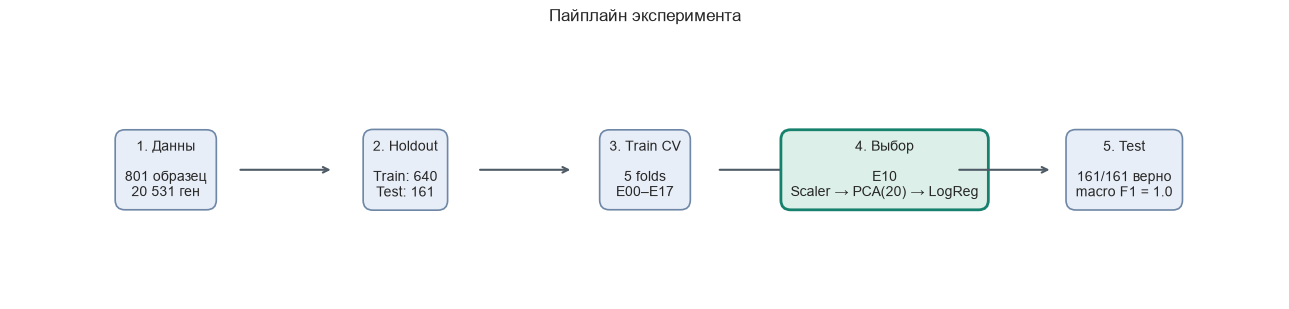

In [2]:
stages = [
    ("1. Данны", "801 образец\n20 531 ген"),
    ("2. Holdout", "Train: 640\nTest: 161"),
    ("3. Train CV", "5 folds\nE00–E17"),
    ("4. Выбор", "E10\nScaler → PCA(20) → LogReg"),
    ("5. Test", "161/161 верно\nmacro F1 = 1.0"),
]

figure, axes = plt.subplots(figsize=(13, 3.2))
for index, (title, details) in enumerate(stages):
    selected = index == 3
    axes.text(
        index,
        0.5,
        f"{title}\n\n{details}",
        ha="center",
        va="center",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.7",
            "facecolor": "#dcefe8" if selected else "#e8eef7",
            "edgecolor": "#16816d" if selected else "#6f87a6",
            "linewidth": 2 if selected else 1.2,
        },
    )
    if index < len(stages) - 1:
        axes.annotate(
            "",
            xy=(index + 0.70, 0.5),
            xytext=(index + 0.30, 0.5),
            arrowprops={"arrowstyle": "->", "color": "#4f5b66", "linewidth": 1.5},
        )

axes.set_title("Пайплайн эксперимента", pad=14)
axes.set_xlim(-0.65, len(stages) - 0.35)
axes.set_ylim(0, 1)
axes.axis("off")
figure.tight_layout()
plt.show()

## 3. Датасет

Основные характеристики и распределение пяти классов.

,Показатель,Значение
0,Образцы,801
1,Признаки,20531
2,Классы,5
3,Train,640
4,Test,161


,Образцы
Класс,
BRCA,300
COAD,78
KIRC,146
LUAD,141
PRAD,136


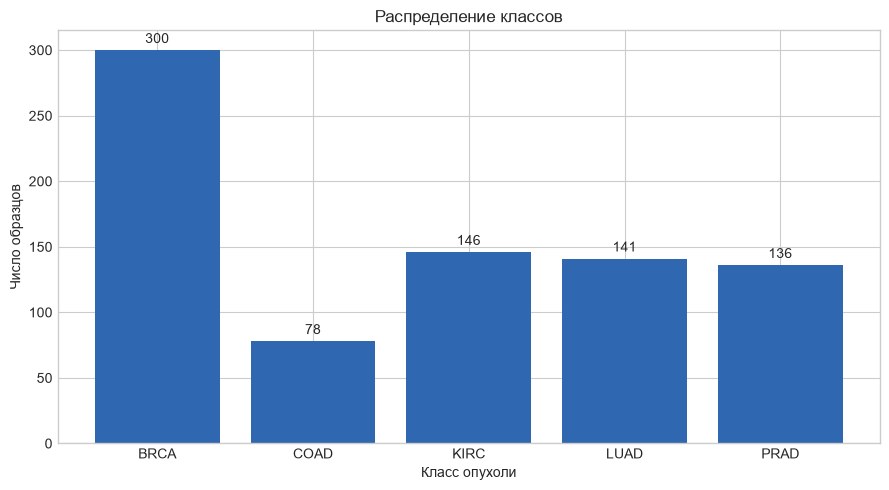

In [3]:
dataset_summary = json.loads(
    (ROOT / "results" / "dataset_summary.json").read_text(encoding="utf-8")
)
split_summary = json.loads((ROOT / "results" / "split_summary.json").read_text(encoding="utf-8"))
final_evaluation = json.loads(
    (ROOT / "results" / "final_evaluation.json").read_text(encoding="utf-8")
)

overview = pd.DataFrame(
    {
        "Показатель": ["Образцы", "Признаки", "Классы", "Train", "Test"],
        "Значение": [
            dataset_summary["sample_count"],
            dataset_summary["feature_count"],
            dataset_summary["class_count"],
            split_summary["train_samples"],
            split_summary["test_samples"],
        ],
    }
)
display(overview)

class_counts = pd.Series(dataset_summary["class_distribution"], name="Образцы")
display(class_counts.rename_axis("Класс").to_frame())

figure, axes = plt.subplots(figsize=(9, 5))
bars = axes.bar(class_counts.index, class_counts.values, color="#2f67b1")
axes.bar_label(bars, padding=3)
axes.set_title("Распределение классов")
axes.set_xlabel("Класс опухоли")
axes.set_ylabel("Число образцов")
figure.tight_layout()
plt.show()

## 4. Сравнение моделей

В таблице показаны ключевые конфигурации. На графике сравнивается
средний CV macro F1 с разбросом по folds.

,experiment_id,model,feature_method,n_features,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean
0,E00,DummyClassifier,none,20531,0.1091,0.0000,0.3750
1,E01,LogisticRegression,none,20531,0.9954,0.0065,0.9953
2,E08,LinearSVC,select_k_best_f_classif,200,1.0000,0.0000,1.0000
3,E10,LogisticRegression,pca,20,1.0000,0.0000,1.0000
4,E16,RandomForestClassifier,select_k_best_f_classif,200,0.9961,0.0032,0.9953
5,E17,PyTorchMLP,select_k_best_f_classif,200,0.9987,0.0026,0.9984


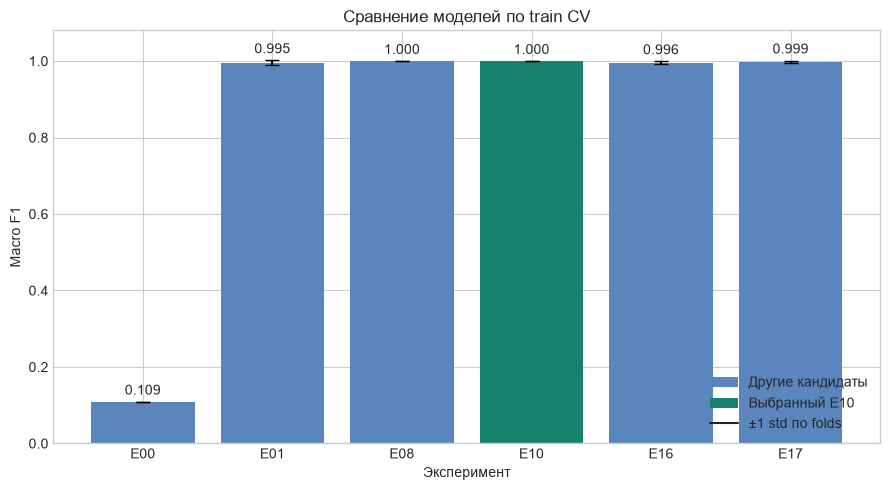

In [4]:
metrics = pd.read_csv(ROOT / "results" / "metrics.csv")
mlp_fold_metrics = pd.read_csv(ROOT / "results" / "mlp_fold_metrics.csv")
comparison_ids = ["E00", "E01", "E08", "E10", "E16", "E17"]
shown_columns = [
    "experiment_id",
    "model",
    "feature_method",
    "n_features",
    "cv_f1_macro_mean",
    "cv_f1_macro_std",
    "cv_accuracy_mean",
]
comparison = (
    metrics.loc[metrics["experiment_id"].isin(comparison_ids), shown_columns]
    .sort_values("experiment_id")
    .reset_index(drop=True)
)
mlp_row = comparison["experiment_id"] == "E17"
comparison.loc[mlp_row, "cv_f1_macro_mean"] = mlp_fold_metrics["f1_macro"].mean()
comparison.loc[mlp_row, "cv_f1_macro_std"] = mlp_fold_metrics["f1_macro"].std(ddof=0)
comparison.loc[mlp_row, "cv_accuracy_mean"] = mlp_fold_metrics["accuracy"].mean()
display(
    comparison.style.format(
        {
            "cv_f1_macro_mean": "{:.4f}",
            "cv_f1_macro_std": "{:.4f}",
            "cv_accuracy_mean": "{:.4f}",
        }
    )
)

figure, axes = plt.subplots(figsize=(9, 5))
bar_colors = [
    "#16816d" if experiment_id == "E10" else "#5b86bd"
    for experiment_id in comparison["experiment_id"]
]
bars = axes.bar(
    comparison["experiment_id"],
    comparison["cv_f1_macro_mean"],
    yerr=comparison["cv_f1_macro_std"],
    capsize=5,
    color=bar_colors,
)
axes.bar_label(bars, fmt="%.3f", padding=3)
axes.set_title("Сравнение моделей по train CV")
axes.set_xlabel("Эксперимент")
axes.set_ylabel("Macro F1")
axes.set_ylim(0, 1.08)
axes.legend(
    handles=[
        Patch(facecolor="#5b86bd", label="Другие кандидаты"),
        Patch(facecolor="#16816d", label="Выбранный E10"),
        Line2D([0], [0], color="#222222", linewidth=1.5, label="±1 std по folds"),
    ],
    loc="lower right",
)
figure.tight_layout()
plt.show()

Столбцы — средний `macro F1` по пяти folds только на train-части, чёрные отрезки —
стандартное отклонение. Это график выбора кандидата, а не финальная test-точность.
Зелёным выделен E10, выбранный для финальной оценки.

## 5. Анализ обучения MLP

История обучения записана для каждого внешнего fold. Таблица содержит
выбранную эпоху, момент early stopping и метрики outer-validation.

Эпохи относятся только к нейросетевому кандидату E17. Итоговый E10 — логистическая регрессия,
поэтому у неё нет графика эпох.

In [5]:
display(
    mlp_fold_metrics.style.format(
        {
            "f1_macro": "{:.4f}",
            "accuracy": "{:.4f}",
            "precision_macro": "{:.4f}",
            "recall_macro": "{:.4f}",
        }
    )
)

mlp_summary_table = pd.DataFrame(
    {
        "Показатель": [
            "Средний CV macro F1",
            "Стандартное отклонение macro F1",
            "Средняя выбранная эпоха",
        ],
        "Значение": [
            mlp_fold_metrics["f1_macro"].mean(),
            mlp_fold_metrics["f1_macro"].std(ddof=0),
            mlp_fold_metrics["selected_epochs"].mean(),
        ],
    }
)
display(mlp_summary_table.style.format({"Значение": "{:.4f}"}))

,fold,selected_epochs,epochs_run,f1_macro,accuracy,precision_macro,recall_macro
0,1,19,29,0.9935,0.9922,0.9959,0.9913
1,2,16,26,1.0000,1.0000,1.0000,1.0000
2,3,4,14,1.0000,1.0000,1.0000,1.0000
3,4,4,14,1.0000,1.0000,1.0000,1.0000
4,5,11,21,1.0000,1.0000,1.0000,1.0000


,Показатель,Значение
0,Средний CV macro F1,0.9987
1,Стандартное отклонение macro F1,0.0026
2,Средняя выбранная эпоха,10.8000


### Train loss и validation loss

- синяя линия — средний train loss;
- оранжевая линия — средний validation loss;
- заливка — диапазон от минимального до максимального значения среди folds.

Обе кривые резко снижаются в первые три эпохи и затем идут согласованно, что соответствует
устойчивому обучению на этих folds.

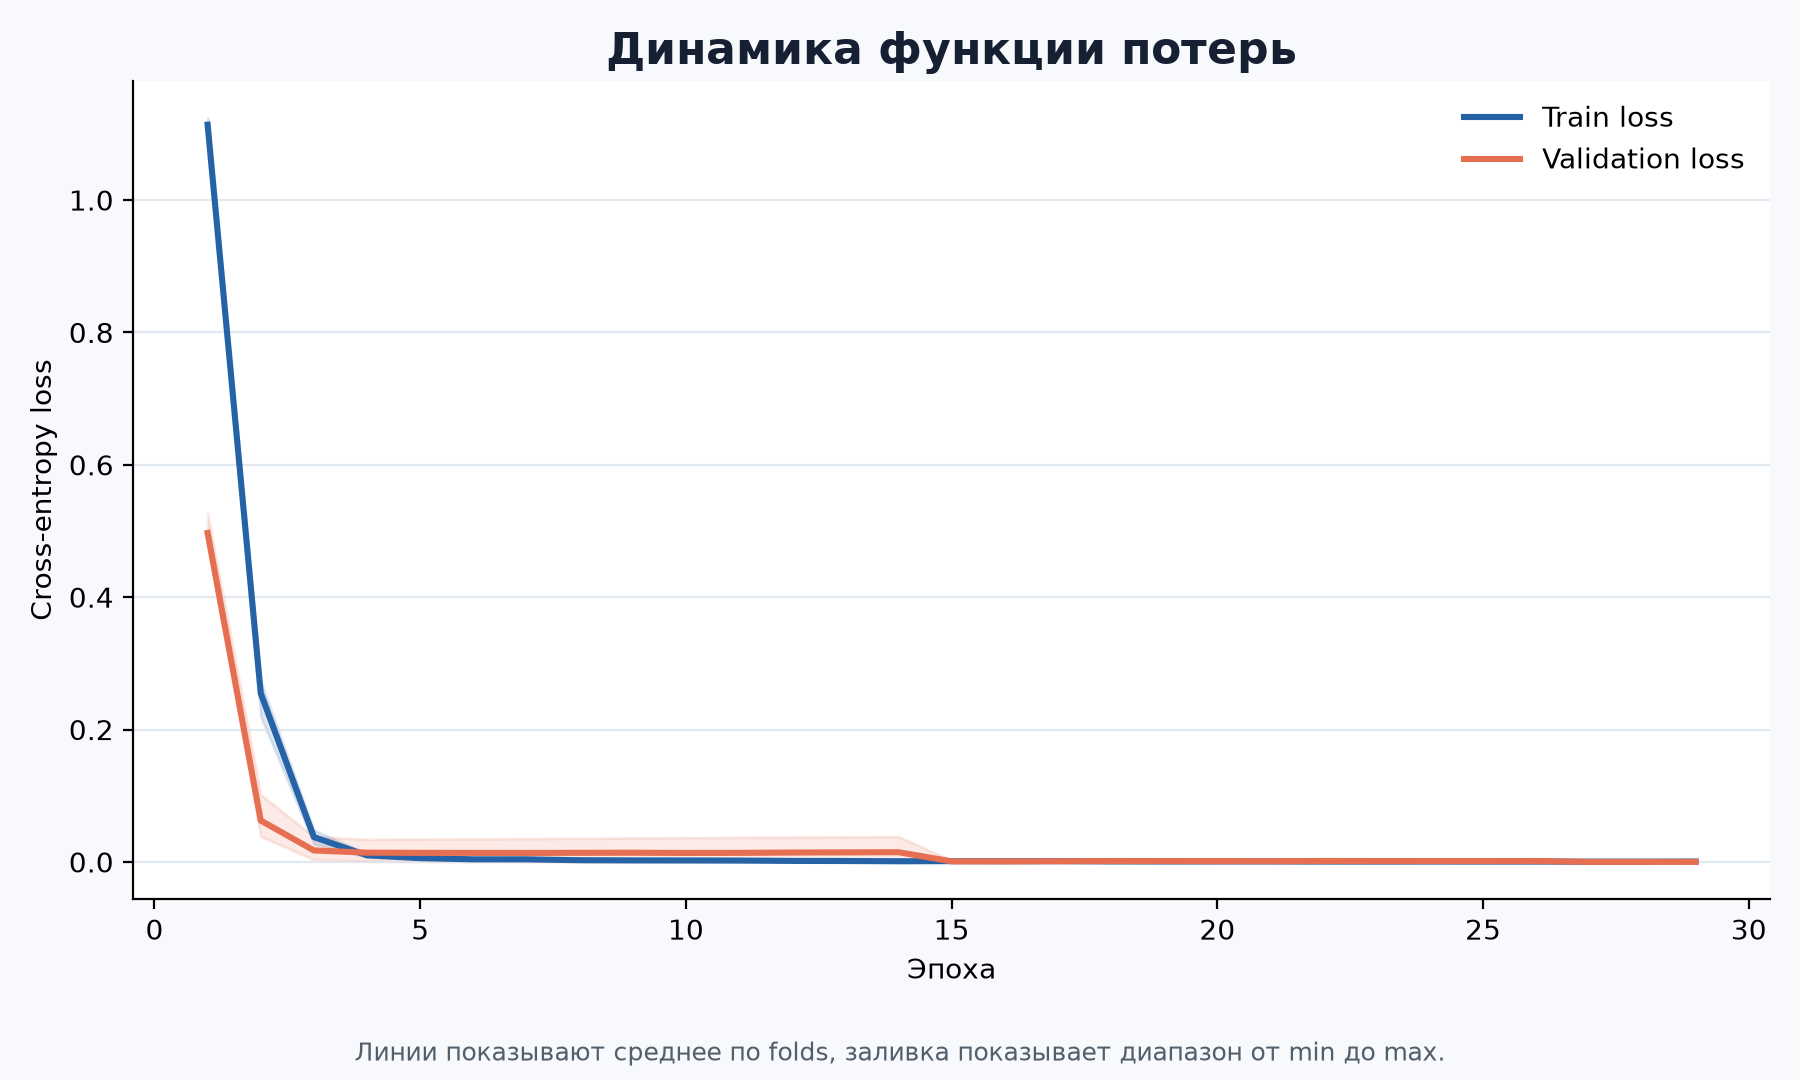

In [6]:
display(Image(filename=str(ROOT / "figures" / "mlp_loss_curves.png")))

### Macro F1 по эпохам

Линия показывает средний validation macro F1, заливка — разброс между folds. Уже в первые
эпохи значение превышает 0.98, а с 15-й эпохи среднее достигает 1.0.

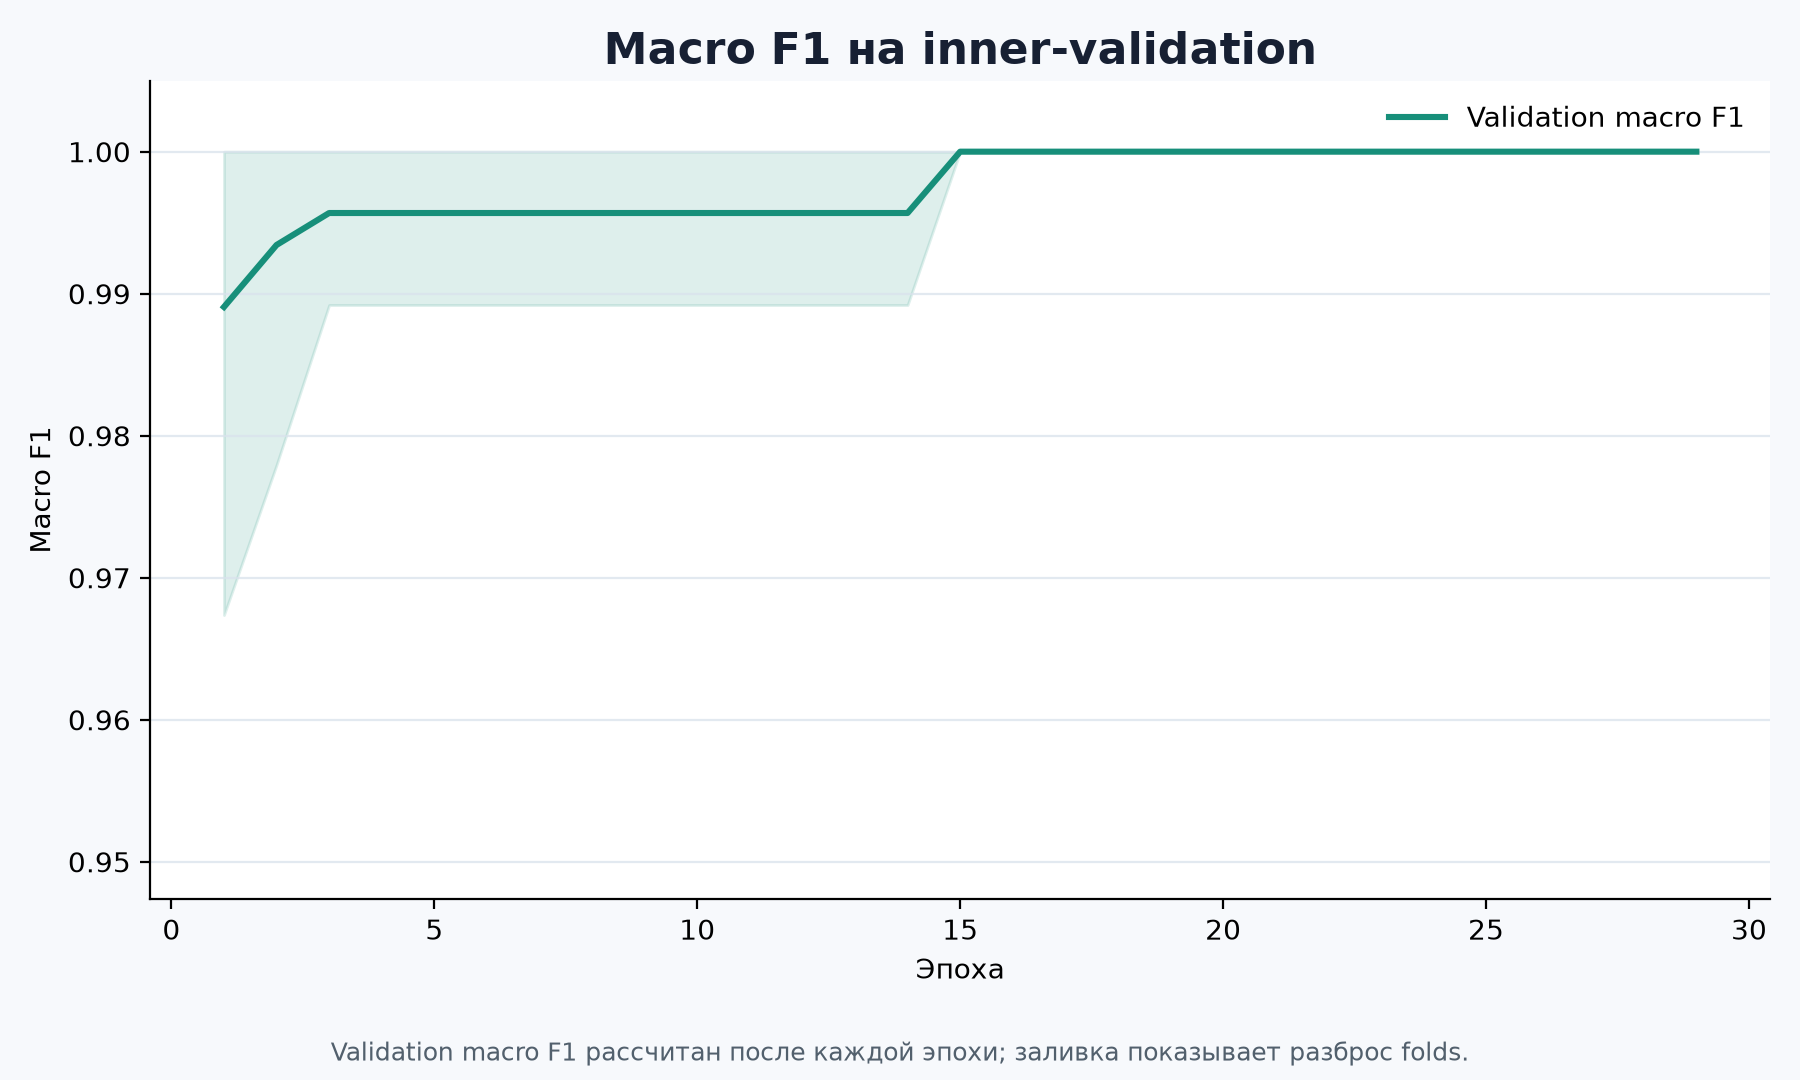

In [7]:
display(Image(filename=str(ROOT / "figures" / "mlp_validation_f1.png")))

### Выбор эпохи и early stopping

- синяя колонка — эпоха с минимальным validation loss;
- жёлтая колонка — фактическая остановка обучения после `patience = 10`.

Различие выбранных эпох показывает, зачем early stopping выполняется отдельно в каждом fold.

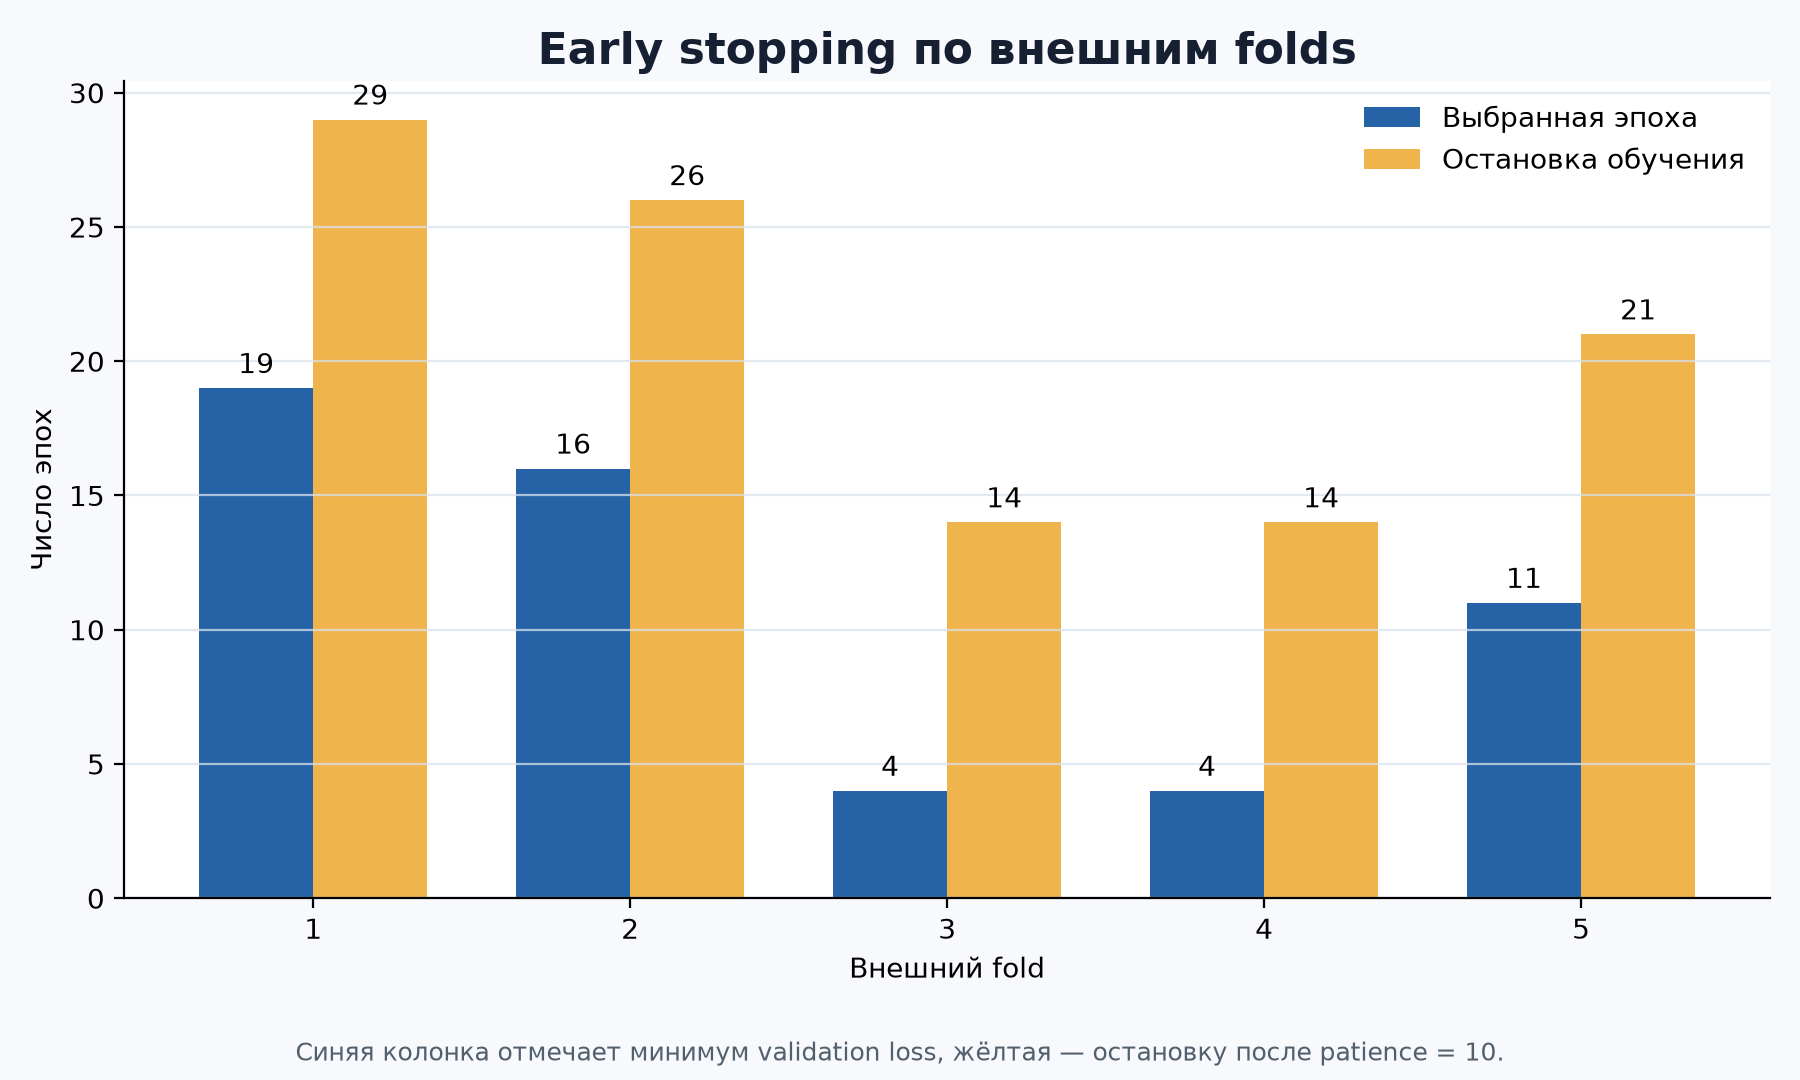

In [8]:
display(Image(filename=str(ROOT / "figures" / "mlp_epoch_selection.png")))

### Macro F1 и accuracy по folds

Зелёные колонки показывают macro F1, фиолетовые — accuracy на outer-validation. В первом
fold получены 0.9935 и 0.9922, в остальных четырёх folds обе метрики равны 1.0.

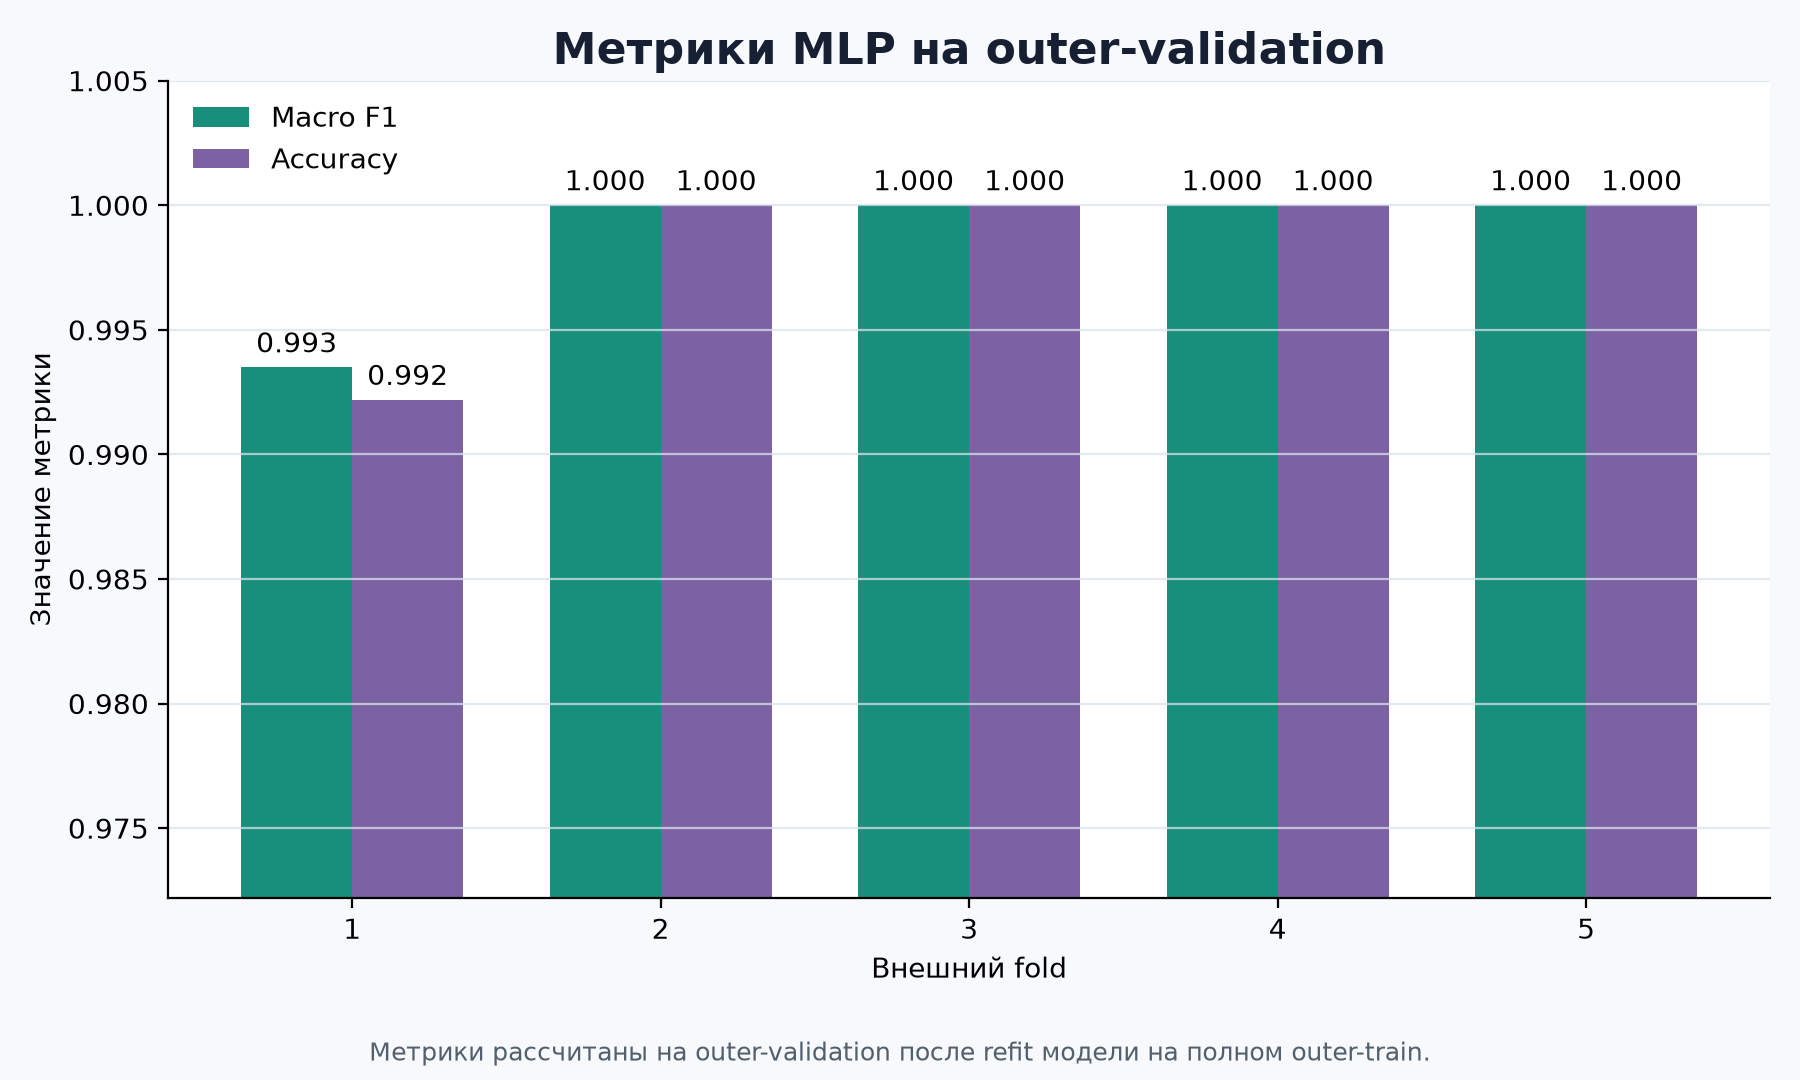

In [9]:
display(Image(filename=str(ROOT / "figures" / "mlp_fold_metrics.png")))

## 6. Проверка устойчивости E10

Повторная кросс-валидация: 10 повторов × 5 folds = 50 оценок только на train-части.
Она показывает, насколько результат зависит от конкретного разбиения данных.

,Метрика,Среднее,Std,Минимум,Максимум
0,Macro F1,0.9980,0.0045,0.9873,1.0000
1,Accuracy,0.9988,0.0029,0.9922,1.0000


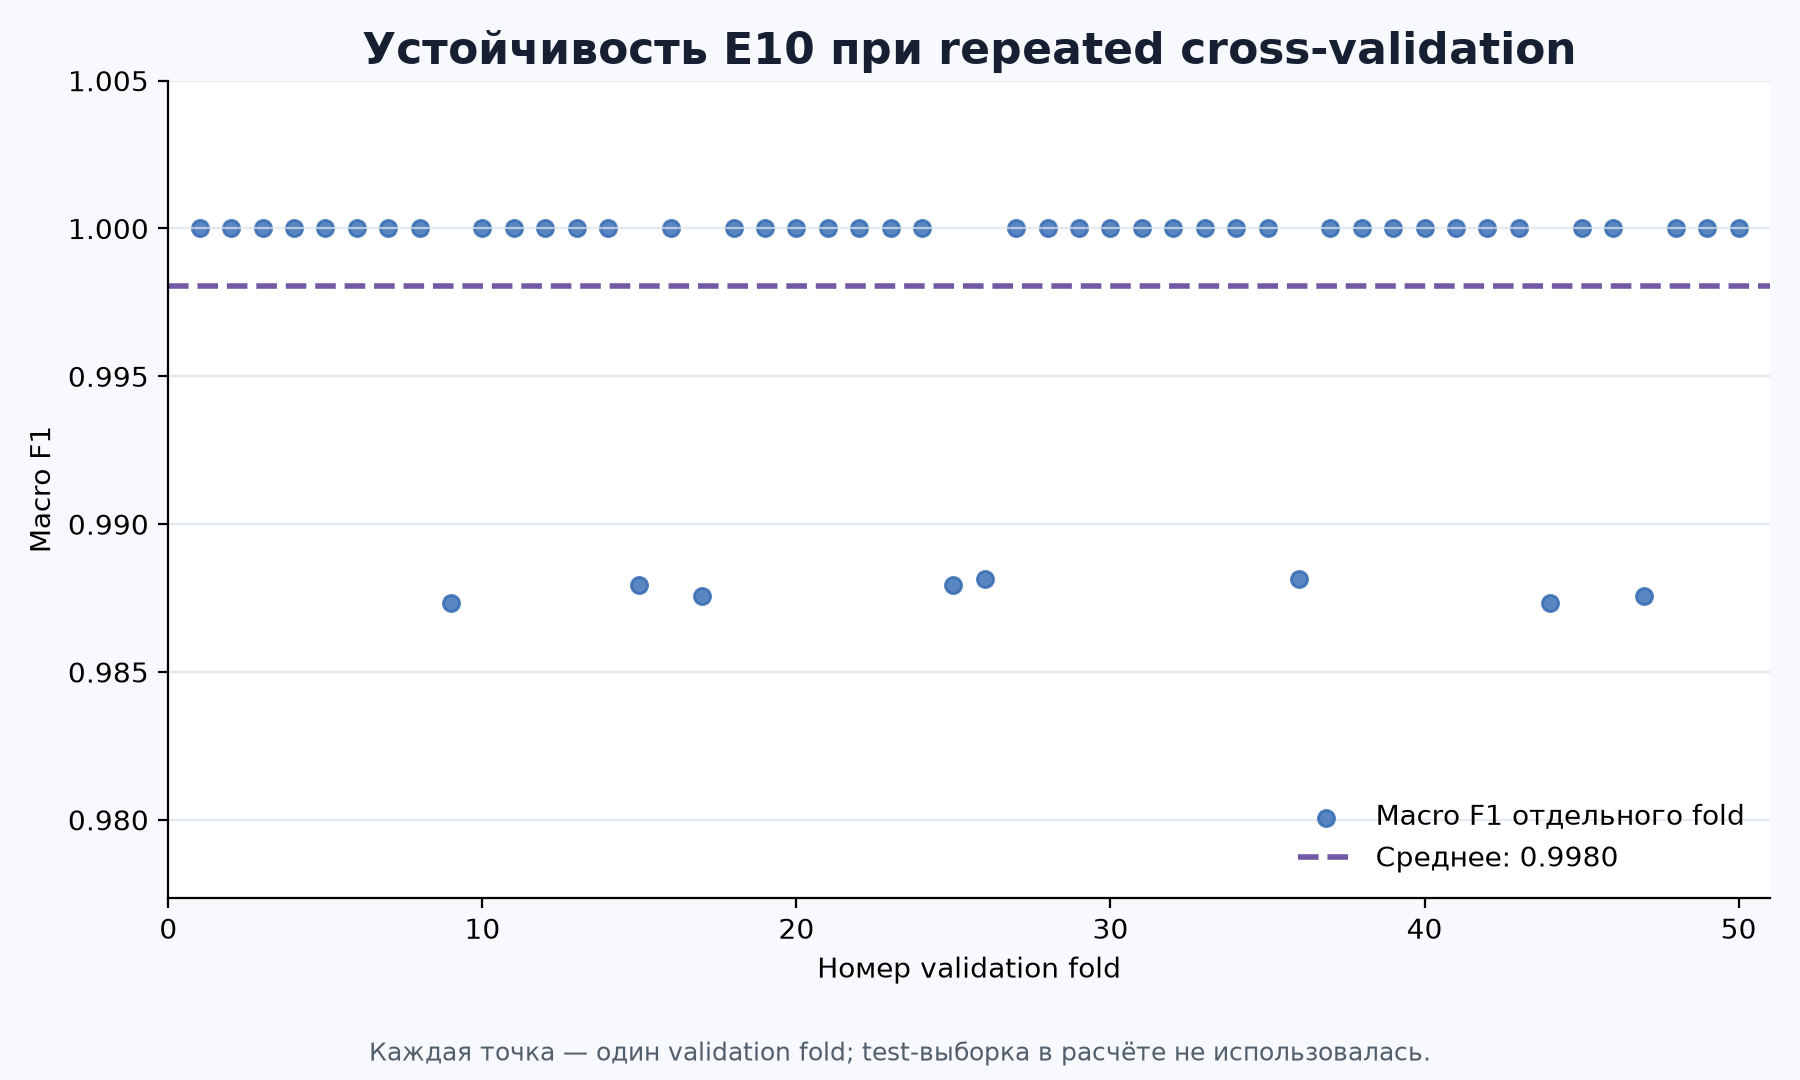

In [10]:
robustness = json.loads((ROOT / "results" / "robustness_e10.json").read_text(encoding="utf-8"))
robustness_table = pd.DataFrame(
    {
        "Метрика": ["Macro F1", "Accuracy"],
        "Среднее": [robustness["f1_macro_mean"], robustness["accuracy_mean"]],
        "Std": [robustness["f1_macro_std"], robustness["accuracy_std"]],
        "Минимум": [robustness["f1_macro_min"], robustness["accuracy_min"]],
        "Максимум": [robustness["f1_macro_max"], robustness["accuracy_max"]],
    }
)
display(robustness_table.style.format(dict.fromkeys(robustness_table.columns[1:], "{:.4f}")))
display(Image(filename=str(ROOT / "figures" / "e10_robustness.png")))

Средний `macro F1 = 0.9980`, минимум по 50 оценкам — `0.9873`.
Поэтому результат близок к 1.0, но не следует трактовать его как гарантию
100% на любых новых данных.

## 7. Финальная оценка

Итоговые метрики E10 на зафиксированной test-выборке из 161 образца.

,Значение
f1_macro,1.0000
accuracy,1.0000
precision_macro,1.0000
recall_macro,1.0000


,Оценка accuracy,Нижняя граница 95%,Верхняя граница 95%,Верно / всего
0,1.0000,0.9767,1.0000,161 / 161


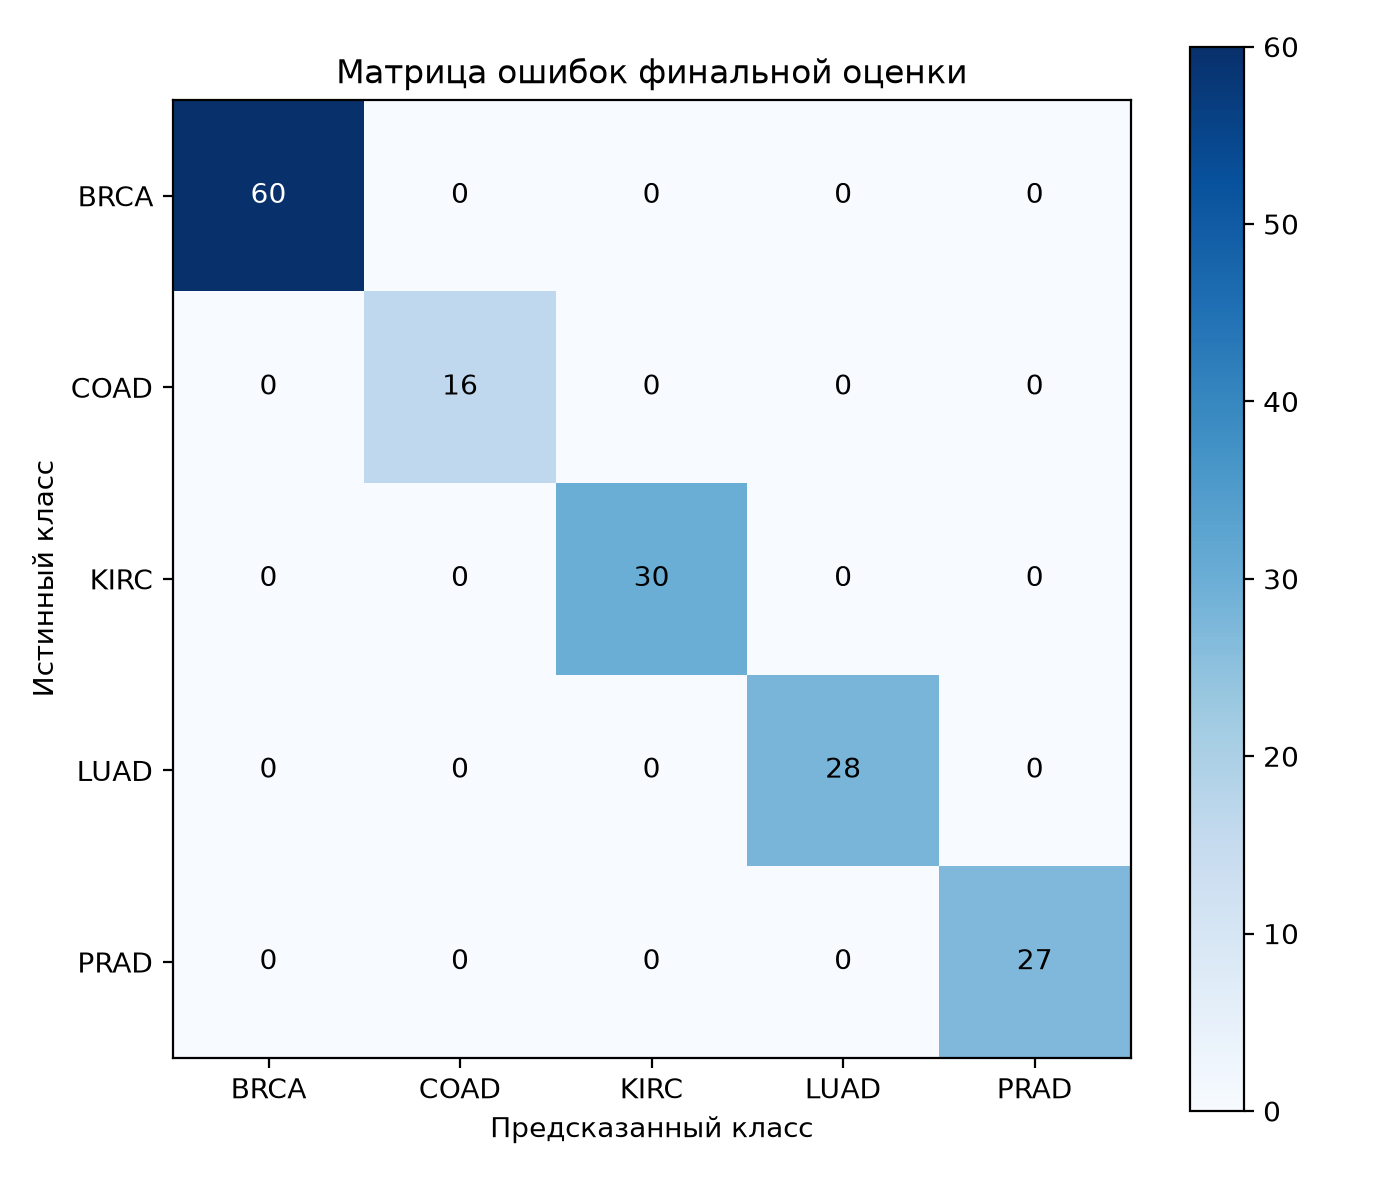

In [11]:
test_metrics = pd.Series(final_evaluation["test_metrics"], name="Значение")
display(test_metrics.to_frame().style.format("{:.4f}"))

statistical_context = json.loads(
    (ROOT / "results" / "statistical_context.json").read_text(encoding="utf-8")
)
interval = statistical_context["accuracy"]
uncertainty_table = pd.DataFrame(
    {
        "Оценка accuracy": [interval["estimate"]],
        "Нижняя граница 95%": [interval["lower"]],
        "Верхняя граница 95%": [interval["upper"]],
        "Верно / всего": [f"{interval['successes']} / {interval['total']}"],
    }
)
display(uncertainty_table.style.format(precision=4))
display(Image(filename=str(ROOT / "figures" / "final_confusion_matrix.png")))

В этом конкретном test-наборе верно классифицированы все 161 образец.
95% интервал Wilson для accuracy равен `0.9767–1.0000` и отражает неопределённость
оценки на конечной выборке.

## 8. Опциональная smoke-проверка модели

Ячейка сверяет predictions готового Pipeline с сохранёнными предсказаниями.
Для обычного показа достаточно оставить переключатель в значении `False`.

In [12]:
RUN_MODEL_SMOKE_TEST = False

if not RUN_MODEL_SMOKE_TEST:
    print("Smoke-проверка отключена.")
else:
    import numpy as np

    from src.app_services import load_final_pipeline
    from src.data_loader import download_dataset, load_dataset
    from src.splitting import split_dataset

    archive_path = download_dataset()
    features, target = load_dataset(archive_path)
    _, features_test, _, _ = split_dataset(features, target)

    model_record = final_evaluation["artifacts"]["model"]
    pipeline = load_final_pipeline(
        ROOT / model_record["path"],
        expected_sha256=str(model_record["sha256"]),
        expected_runtime=final_evaluation["runtime"],
    )
    predictions = np.asarray(pipeline.predict(features_test), dtype=str)
    saved_predictions = pd.read_csv(ROOT / "results" / "final_test_predictions.csv")
    expected = (
        saved_predictions.set_index("sample_id")
        .loc[features_test.index.astype(str), "predicted_label"]
        .to_numpy(dtype=str)
    )
    assert np.array_equal(predictions, expected)
    print(f"Совпали все {len(predictions)} predictions.")

Smoke-проверка отключена.


## 9. Вывод

На train cross-validation лучшие линейные конфигурации получили macro F1 около 1.0.
Для финального Pipeline выбран E10:
`StandardScaler → PCA(20) → LogisticRegression`.

Анализ MLP показывает быстрое снижение loss, выход macro F1 к 1.0
и различное число выбранных эпох в пяти folds. Повторная CV даёт средний
`macro F1 = 0.9980`, а 100% относится только к зафиксированной test-выборке.